In [2]:
import torch    
import torch_geometric.transforms as T
import mdtraj as md
import os
import torch 
import numpy as np
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data, Dataset
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import BatchNorm1d
from torch_geometric.nn import GATConv, global_mean_pool, GCNConv, knn_graph, Linear
from torch.optim import SGD, Adam, Optimizer
import math
from torch.nn.init import kaiming_uniform_
from torch_geometric.transforms import ToDevice
import scipy
import sys
from e3nn.io import CartesianTensor
from torch_geometric.loader import DataLoader

device='cuda'
torch.cuda.is_available()

True

In [3]:
from rdkit import Chem
mol = Chem.MolFromPDBFile("../Sim9/an1_water.pdb", removeHs=False)
Chem.SanitizeMol(mol)

import MDAnalysis as mda

top ='../Sim9/equil5.gro'
Sim=2 # not 2,3,7
t = "../Sim%d/fit2.dcd"%Sim
u = mda.Universe(top, t)

In [4]:
# from rdkit import Chem
# mol = Chem.MolFromPDBFile("an1.pdb", removeHs=False)
# Chem.SanitizeMol(mol)

# top ='../Sim9/equil5.gro'
# Sim=9 # not 2,3,7
# t = "../Sim%d/frame_32041_allAtoms_translated.pdb"%Sim
# traj = md.load(t, top=top)

# xyz = torch.tensor(traj.xyz) * 10
# ele2num = {"C": 0, "H": 1, "O": 2, "N": 3, "S": 4, "VS": {"FE": 5, "MG":6}} # all 0's will be padding for gases not within 3.5 angstroms of any protein atom
ele2num = {"C": 0, "H": 1, "O": 2, "N": 3, "S": 4, "Fe": 5, "Mg":6, "Na":7, "Cl":8}
t = "../Sim%d/an1_water.pdb"%9
traj = md.load_frame(t, index=0,top=top)
gas='O2IF'
metal='FE'
gas2 = traj.topology.select('resname %s' % gas)
residue_ref = np.array([traj.topology.atom(ind).residue.resSeq for ind in gas2])
FE = traj.topology.select('resname Fe2p')
residue_sel_un = np.unique(residue_ref) # gas
residue_sel_un

print('LEN FE', FE)
residue_sel_un = np.unique(residue_ref) # gas
residue_sel_un
nogas = np.setdiff1d(range(0,traj.xyz.shape[1]),gas2)
rnames = np.array([traj.topology.atom(ind).residue.name for ind in nogas])
rindex = np.array([traj.topology.atom(ind).residue.resSeq for ind in nogas])
anames = np.array([traj.topology.atom(ind).element.symbol for ind in nogas])
anames2=np.array([traj.topology.atom(i).name for i in nogas])
anums = [ele2num[a] if a != 'VS' else ele2num[a][metal] for a in anames]

# rnames = np.array([traj.topology.atom(ind).residue.name for ind in nogas])
# rindex = np.array([traj.topology.atom(ind).residue.resSeq for ind in nogas])
# anames = np.array([traj.topology.atom(ind).element.symbol for ind in nogas])
rnames2 = np.array([traj.topology.atom(ind).residue for ind in nogas])

cat = np.where(anames=='Fe')[0]
print(cat)

device = torch.device("cpu")
# device = torch.device("cpu")
# protein_coords_traj = xyz[:,nogas,:]
rs = int(len(residue_ref)/len(residue_sel_un))
gas_atoms=gas2.reshape(len(residue_sel_un),2)

# dioxygen_coords_ave = xyz[:,gas2,:].reshape(-1,len(residue_sel_un),rs,3).mean(axis=2)
# d=torch.cdist(dioxygen_coords_ave, xyz[:,cat,:])
# diox = np.where(d < 6.0)[1]
# frames = np.where(d < 6.0)[0]

types_array_atom = torch.zeros((len(nogas)+len(gas2), (len(ele2num))))
for i, t in enumerate(anums):
    types_array_atom[i,t] = 1.0
# types_array_atom.shape
types_array_atom[-len(gas2):,ele2num['O']] = 1
types_array_atom = types_array_atom.to(device)

gas_idx = np.where(residue_sel_un==10000)[0]
gas_idx
# protein_cofactors = torch.tensor(nogas).to(device)
# global_to_local = {int(g): i for i, g in enumerate(np.arange(0,xyz[:,nogas,:].shape[1]))}
protein_cofactors = torch.tensor(np.setdiff1d(np.arange(0,len(u.atoms)), gas_atoms[gas_idx])).to(device)
global_to_local = {int(g): i for i, g in enumerate(protein_cofactors)}

del traj

t = "../Sim9/fit2_small.dcd"
traj = md.load_frame(t, index=0,top="../Sim9/equil5.gro")
rnames2 = np.array([traj.topology.atom(ind).residue for ind in protein_cofactors])
anames2=np.array([traj.topology.atom(i).name for i in protein_cofactors])

/home/bw973/.conda/envs/holoprot/lib/python3.10/site-packages/mdtraj/formats/pdb/pdbstructure.py:579: UserWarning: WARNING: two consecutive residues with same number (ATOM      7  N   GLN A 184      19.741  63.070  54.031  1.00  0.00           N  , ATOM      6  O   ACE A 184      17.771  62.964  52.900  1.00  0.00           O  )
  warnings.warn(
/home/bw973/.conda/envs/holoprot/lib/python3.10/site-packages/mdtraj/formats/pdb/pdbstructure.py:579: UserWarning: WARNING: two consecutive residues with same number (ATOM   3506  N   ASP B 558      51.654  33.652  33.228  1.00  0.00           N  , ATOM   3505  O   ACE B 558      49.858  33.843  31.862  1.00  0.00           O  )
  warnings.warn(


LEN FE [3790]
[3790]


/home/bw973/.conda/envs/holoprot/lib/python3.10/site-packages/mdtraj/formats/gro.py:364: UserWarning: WARNING: two consecutive residues with same number (GLN, ACE)
  warnings.warn(
/home/bw973/.conda/envs/holoprot/lib/python3.10/site-packages/mdtraj/formats/gro.py:364: UserWarning: WARNING: two consecutive residues with same number (ASP, ACE)
  warnings.warn(


In [5]:
# types_array_atom.shape
def build_complete_edge_index(N, device):
    idx = torch.arange(N, device=device)
    i, j = torch.meshgrid(idx, idx, indexing="ij")

    mask = i != j  # no self-loops
    edge_index = torch.stack([i[mask], j[mask]], dim=0)
    return edge_index

# DO THIS ONCE
global_bonds = []  # (a1, a2, order)

for bond in mol.GetBonds():
    a1 = bond.GetBeginAtomIdx()
    a2 = bond.GetEndAtomIdx()

    if a1 in gas_atoms or a2 in gas_atoms:
        continue

    bt = bond.GetBondType()
    order = (
        1 if bt == Chem.rdchem.BondType.SINGLE else
        2 if bt == Chem.rdchem.BondType.DOUBLE else
        3 if bt == Chem.rdchem.BondType.AROMATIC else
        1
    )

    global_bonds.append((a1, a2, order))
    global_bonds.append((a2, a1, order))

# gas bonds
for a1, a2 in gas_atoms:
    global_bonds.append((a1, a2, 1))
    global_bonds.append((a2, a1, 1))


from torch_geometric.data import Data
def extract_point_cloud(atom_matrix, positions, center):
    """
    Formats the already-cropped atom features and positions into a Data object.
    """
    if positions.shape[0] == 0:
        return None  # Skip empty cubes

    # Center coordinates relative to cube center
    centered_positions = positions - center

    return Data(x=atom_matrix, pos=centered_positions)

path_dict = {
    'P1':'P1', 
    'P_main (PmR)':'PmR', 
    'P_main (mid)':'mid', 
    'P_reverse':'P_reverse', 
    'P_main (PmL)':'PmL',
       'P3':'P3'
}

def write_pdb2(inds, what, xs, ys, zs, chain='C', file="ml_out.pdb"):
    
    print(file)
    
    fpdb = open("pdbs/%s"%file, 'wt')
    norm = torch.max(what[inds])
    i_atom = 1
    i_resid = 1
    for i, dind in enumerate(inds):

        fpdb.write('{:6s}{:5d} {:^4s}{:1s}{:3s} {:1s}{:4d}{:1s}   {:8.3f}{:8.3f}{:8.3f}{:6.2f}{:6.2f}          {:>2s}{:2s}\n'.format(
            'ATOM',i_atom,
            'GG','','GG',
            chain,i_resid,'',
            xs[dind],ys[dind],zs[dind],
            -1.0*torch.log10(what[dind]/norm),(what[dind]),
            'K',''))
        i_atom += 1
        if i_atom > 999:
            i_atom = 1
            i_resid += 1
            #eigv[dind,0],mm.pi[dind],
    fpdb.write('TER\n')
    fpdb.close()

def axis_without_center(minv, maxv, space, hole=3.5):
    left  = np.arange(minv, -hole, space)
    right = np.arange(hole, maxv + space, space)
    return np.concatenate([left, right])

import numpy as np
import torch


def get_points(
    start,
    translated,          # [N_atoms, 3]
    frame_pos,           # [3]
    space=0.65,
    bottom_threshold=2.5,
    top_threshold=3.5,
    min_radius=0.,
    max_radius=30.,
    distance_to=20.0,
    chunk_size=2048,
):
    """
    Generate grid points, exclude points too close to atoms,
    and keep points near frame_pos.

    Memory safe: no full distance matrix.
    """

    device = translated.device

    # ---------------------------------------------------------
    # 1. Grid extent selection
    # ---------------------------------------------------------
    if distance_to <= 7.5:
        extent = 11
    elif distance_to <= 9:
        extent = 13
    elif distance_to <= 12:
        extent = 16
    else:
        extent = 25

    edges = np.arange(-extent, extent + space, space)

    # ---------------------------------------------------------
    # 2. Generate spherical shell grid
    # ---------------------------------------------------------
    pts = []
    rmin2 = 3.5 ** 2
    rmax2 = extent ** 2

    for x in edges:
        x2 = x * x
        for y in edges:
            xy2 = x2 + y * y
            if xy2 > rmax2:
                continue
            for z in edges:
                r2 = xy2 + z * z
                if rmin2 <= r2 <= rmax2:
                    pts.append((x, y, z))

    points_3d = torch.tensor(pts, dtype=torch.float32, device=device)

    # ---------------------------------------------------------
    # 3. Cull atoms that can never affect kept points
    # ---------------------------------------------------------
    # Worst-case geometry bound
    print(torch.norm(frame_pos), max(max_radius, distance_to), top_threshold)
    max_relevant = torch.norm(frame_pos) + max(max_radius, distance_to) + top_threshold

    atom_dist = torch.norm(translated, dim=1)
    atom_mask = atom_dist <= max_relevant
    exclude_points = translated[atom_mask]

    # ---------------------------------------------------------
    # 4. Distance-based exclusion (chunked)
    # ---------------------------------------------------------
    min_dist = torch.full(
        (points_3d.shape[0],),
        float("inf"),
        device=device
    )

    for i in range(0, exclude_points.shape[0], chunk_size):
        ep = exclude_points[i:i + chunk_size]
        d = torch.cdist(points_3d, ep)           # [P, chunk]
        min_dist = torch.minimum(min_dist, d.min(dim=1).values)

    # outside bottom_threshold AND inside top_threshold
    valid = (min_dist >= bottom_threshold) & (min_dist < top_threshold)
    filtered_points = points_3d[valid]

    # ---------------------------------------------------------
    # 5. Final restriction around frame_pos
    # ---------------------------------------------------------
    dist_to_frame = torch.norm(filtered_points - frame_pos, dim=1)

    
    filtered_points = filtered_points[(dist_to_frame <= max_radius) & (dist_to_frame >= min_radius)]

    return filtered_points



def get_fe_bias(
    xyz2,
    frame_pos,
    point=None,
    alpha=10.0,
    beta=1.0,
    denom=4,
    range_=0.75,
):
    """
    alpha → dominance of reference-point distance
    beta  → influence of closeness to the line
    point → reference point [3], defaults to origin
    """

    if point is None:
        point = torch.zeros(3, device=xyz2.device, dtype=xyz2.dtype)
    else:
        point = torch.as_tensor(point, device=xyz2.device, dtype=xyz2.dtype)

    # Shift coordinates so "point" becomes the origin
    xyz_rel = xyz2 - point  # [N, 3]

    # ------------------------------
    # Distance to reference point (dominant term)
    # ------------------------------
    dist_point = torch.norm(xyz_rel, dim=1)  # [N]
    origin_score = 1.0 / (dist_point**denom + 1e-8)

    # ------------------------------
    # Distance to line through `point`
    # ------------------------------
    line_dir = frame_pos / torch.norm(frame_pos)  # [3]
    t = (xyz_rel * line_dir).sum(dim=1, keepdim=True)
    d_perp = torch.norm(xyz_rel - t * line_dir, dim=1)

    line_score = 1.0 / (d_perp + 1e-8)

    # ------------------------------
    # Combine WITHOUT global normalization
    # ------------------------------
    combined = alpha * origin_score + beta * line_score

    # ------------------------------
    # Scale result to 0–range_ while preserving ranking
    # ------------------------------
    combined_min = combined.min()
    combined_max = combined.max()

    score = range_ * (combined - combined_min) / (combined_max - combined_min + 1e-8)

    return score


import torch
def get_best(density, pos_embedding, k=5):
# points: [N,3], density: [N]
    # k = 5
    points = torch.stack([p.center for p in pos_embedding])
    # density=density
    N = points.shape[0]

    best_sum = -1
    best_group = None
    best_ndx = None
    scores = {}

    for i in range(N):
        # compute distances from point i
        dists = torch.norm(points - points[i], dim=1)  # [N]
        
        # find indices of the closest k points including self
        _, nn_idx = torch.topk(-dists, k)  # negative because topk returns largest
        
        # sum densities in this group
        group_density = density[nn_idx].sum()
        scores[i] = {}
        scores[i]['group_density'] = group_density
        scores[i]['nn_idx'] = nn_idx
        
        if group_density > best_sum:
            best_sum = group_density
            best_group = nn_idx
            best_ndx = i

    highest_cluster_points = points[best_group]
    highest_cluster_density = density[best_group]

    return scores, points


def topk_with_radius(density, pos_embedding, k=5, radius=2.0, threshold=0.5):
    have_pos = True
    density = density.to('cpu')
    points = torch.stack([p.center for p in pos_embedding])
    keep = torch.where(density > threshold)[0]
    above_p1 = any(density > 0.1)
    while len(keep) < (2*k):
        print(len(keep),threshold)
        threshold = threshold/2
        if np.isclose(0,threshold,.001):
            break
        keep = torch.where(density > threshold)[0]
        if threshold < 0.1 and k == 1 and not above_p1:
            have_pos = False
            break
        if threshold < 0.1:
            k=1
            threshold = 0.5
            keep = torch.where(density > threshold)[0]
        print(len(keep),threshold)
    points = points[keep]
    density = density[keep]
    print("Keeping:", density.shape, ", at score >=", threshold)
    N = points.shape[0]
    best_sum = -1
    best_group = None
    best_ndx = None
    scores = {}

    for i in range(N):
        # distances from point i
        dists = torch.norm(points - points[i], dim=1)

        # initial K nearest indices (including itself)
        _, nn_idx = torch.topk(-dists, k)

        # extract positions of candidate group
        group_pts = points[nn_idx]            # [k,3]

        # compute pairwise distance matrix within group
        pdist = torch.norm(
            group_pts.unsqueeze(1) - group_pts.unsqueeze(0),
            dim=2
        )  # [k, k]
        # check radius requirement: all pairwise distances ≤ radius
        if (pdist <= radius).all():
            group_density = density[nn_idx].sum()

            if group_density > best_sum:
                best_sum = group_density
                best_group = nn_idx
                best_ndx = i
            scores[i] = {}
            scores[i]['group_density'] = group_density
            scores[i]['nn_idx'] = nn_idx

    return scores, points, have_pos

# Map from global RDKit atom idx → local 0..N-1
import itertools

def build_edges_and_attrs_fast(inside_indices, edge_index_cache):
    device = inside_indices.device
    N = inside_indices.shape[0]

    # global → local
    atom_to_local = {int(a): i for i, a in enumerate(inside_indices.tolist())}

    # edge_index is reused
    edge_index = edge_index_cache

    # initialize all nonbonded = 0
    edge_attr = torch.zeros(
        (edge_index.shape[1], 1),
        dtype=torch.long,
        device=device
    )

    # overwrite bonded edges only
    # map (i,j) → edge position once
    edge_pos = {
        (int(i), int(j)): k
        for k, (i, j) in enumerate(edge_index.t().tolist())
    }

    for a1, a2, order in global_bonds:
        if a1 in atom_to_local and a2 in atom_to_local:
            i = atom_to_local[a1]
            j = atom_to_local[a2]
            edge_attr[edge_pos[(i, j)], 0] = order

    return edge_index, edge_attr



def embed(xyz2, step, protein_coords_list,protein_cofactors,global_to_local, radius=5, frame_emb=None):
    print("STEP:", step)
    # xyz2:  grid point coordinates for the frame we are trying to predictt, i.e. the next frame, 
    # frame_pos: the given O2 in frame 0
    # first frame frame_pos for O2 is given, each one after is prediction from one before
    # 0 is first step which is given and we start to predict from 1

    pos_embedding = []
    xyz = []
    atom_coords = protein_coords_list
    
    # print(dist)
    min_dist = 2.5
    
    for i, point in enumerate(xyz2[0:]):
        center = point
        dist = torch.norm(center - atom_coords[cat[0],:])
      
      
        # radius = 6.0

        # Compute distances of all atoms to perturbed point
        dists = torch.norm(atom_coords - center, dim=1)

        # Indices of atoms inside sphere
                    # Indices of atoms inside sphere
        inside_indices = protein_cofactors[torch.where(dists <= radius)[0]]

        # Ensure inside_indices is always a 1D tensor
        if torch.is_tensor(inside_indices) and inside_indices.ndim == 0:
            inside_indices = inside_indices.unsqueeze(0)

        if isinstance(inside_indices, (int, np.integer)):
            inside_indices = torch.tensor([inside_indices], device=device)

        if inside_indices.numel() == 0:
            dddd = torch.cdist(center.unsqueeze(0), atom_coords)
            print('too far start or end', dddd.min(), flush=True)
            continue
        xyz.append(i)
        local_inside_indices = np.array([global_to_local[int(g)] for g in inside_indices])

        atom_matrix=types_array_atom[inside_indices]
        positions=atom_coords[local_inside_indices]
        node_directions = positions - atom_coords[cat[0],:]
        node_distances = torch.norm(node_directions, dim=1)
        local_pos_normalized = (positions - center)/radius  # shape [N, 3]
        
        # atom_matrix_arr.append(atom_matrix)
        # positions_arr.append(positions)
        test = extract_point_cloud(atom_matrix, positions, center)
        # test.x=torch.column_stack([test.x, torch.tensor(frame_emb[idx]).repeat(len(test.x))])
        if frame_emb is not None:
            frame_vector = frame_emb[step]          # [16]
            frame_vector = frame_vector.unsqueeze(0)           # [1, 16]
            frame_vector = frame_vector.expand(len(test.x), -1)  # [N, 16]
            test.distance = dist.expand(len(test.x))
            test.x = torch.cat([test.x, frame_vector], dim=1)    # [N, 6 + 16]

        # print("bulding edges for point:", i+1)
        N=len(inside_indices)
        edge_index_cache = build_complete_edge_index(N, 'cpu')
        # test.edge_index, test.edge_attr = build_edges_and_attrs(inside_indices)
        test.edge_index, test.edge_attr = build_edges_and_attrs_fast(inside_indices, edge_index_cache)
        # print("\tdone bulding edges for point:", i+1)
        test.inside_indices = inside_indices
        test.local_inside_indices = local_inside_indices
        test.center = center
        test.node_attr = local_pos_normalized
        test.node_directions = node_directions
        test.node_distances = node_distances
        pos_embedding.append(test)
    # print("DOEN")
    xyz2 = xyz2[xyz]
    return xyz2, pos_embedding

import torch
import math

def predict(pos_embedding, model, bs=5, frame_emb_bool=False, node_input_bool=False, atom_as_node_attr=False):
    # model = torch.load('../Sim1/model.pt') # 
    # model=torch.load("../Sim5/model%d_FE2dis_inr6.pt"%24)
    model=torch.load(model)
    device='cuda'
    model = model.to(device)


    test_loader = DataLoader(pos_embedding, batch_size=bs, shuffle=False) 


    values = []
    with torch.no_grad():
        for batch_idx, (data_list) in enumerate(test_loader):
            torch.cuda.empty_cache()
            if (batch_idx + 1) % 50 == 0:
                print("Batch",batch_idx+1, flush=True)
            if isinstance(data_list, list):
                from torch_geometric.data import Batch
                batch = Batch.from_data_list(data_list)
            else:
                batch = data_list  # if batch_size=1, it might already be a Data object

            batch = batch.to('cuda')
            

            
            distance = torch.norm(batch.node_attr[:, :3], dim=1, keepdim=True)  # [N, 1]

            # 2. Convert Cartesian vectors to irreps vector
            x = CartesianTensor("i")
            vector_irrep = x.from_cartesian(batch.node_attr[:, :3])  # [N, 3]

          
            atom_type_onehot = batch.x[:, 0:9]
            
            frame_emb = batch.x[:, 9:] 
            if frame_emb_bool:
                if atom_as_node_attr:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        atom_type_onehot,    # 6 scalars (0e)
                        frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)
                else:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        # atom_type_onehot,    # 6 scalars (0e)
                        frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)

            else:
                # node_attr = torch.cat([distance, vector_irrep, frame_emb], dim=1)
                if atom_as_node_attr:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        atom_type_onehot,    # 6 scalars (0e)
                        # frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)
                else:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        # atom_type_onehot,    # 6 scalars (0e)
                        # frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)

            
            # node_input = torch.ones((batch.num_nodes, 1), device=batch.x.device)
            if node_input_bool:
                node_input = torch.cat([
                    # batch.distance.unsqueeze(-1), # 1 scalar (0e) distance of center of graph to iron
                    batch.node_distances.unsqueeze(-1),    # 1 scalar (0e) distance to iron for each atom
                    F.normalize(batch.node_directions, p=2, dim=1),        # 3-vector (1o) direction to iron for each atom
                ], dim=1)
            else:
                node_input = torch.ones((batch.num_nodes, 1), device=batch.x.device)

            if not atom_as_node_attr:
                data = {
                "batch": batch.batch,
                # "x": batch.x[:,0:6], # atom type
                # "frame_emb": frame,
                "x": atom_type_onehot,
                "node_attr": node_attr, 
                "edge_index": batch.edge_index,
                "edge_attr": batch.edge_attr,
                "pos": batch.pos,  # if needed in preprocess
            }
            else:
                data = {
                    "batch": batch.batch,
                    # "x": batch.x[:,0:6], # atom type
                    # "frame_emb": frame,
                    "x": node_input,
                    "node_attr": node_attr, 
                    "edge_index": batch.edge_index,
                    "edge_attr": batch.edge_attr,
                    "pos": batch.pos,  # if needed in preprocess
                }

            outputs = model(data)
            preds = torch.sigmoid(outputs.squeeze(-1))
            values.append(preds)
            torch.cuda.empty_cache()

        results = torch.concat(values)
        best = results.argmax() # 2552
        best_pos = best#xyz2[best]
        return best, best_pos, results

def sinusoidal_embedding(frame_idx: torch.Tensor, dim: int = 16):
    """
    frame_idx: tensor of shape [N] with normalized frame values in [0,1]
    dim: embedding dimension (should be even)
    Returns: tensor of shape [N, dim]
    """
    device = frame_idx.device
    N = frame_idx.size(0)
    pe = torch.zeros(N, dim, device=device)

    position = frame_idx.unsqueeze(1)  # [N, 1]
    div_term = torch.exp(torch.arange(0, dim, 2, device=device) * -(math.log(10000.0) / dim))  # [dim/2]

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # [N, dim]

    

In [11]:
scores, points, hp = topk_with_radius(results_biased, pos_embedding, k=3, radius=3, threshold=0.5)

0 0.5
0 0.25
0 0.25
1 0.125
1 0.125
0 0.5
0 0.5
0 0.25
0 0.25
1 0.125
1 0.125
Keeping: torch.Size([1]) , at score >= 0.0625


In [6]:
def topk_with_radius(density, pos_embedding, k=5, radius=2.0, threshold=0.5):
    have_pos = True
    density = density.to('cpu')
    points = torch.stack([p.center for p in pos_embedding])
    keep = torch.where(density > threshold)[0]
    above_p1 = any(density > 0.1)
    while len(keep) < (2*k):
        print(len(keep),threshold)
        threshold = threshold/2
        if np.isclose(0,threshold,.001):
            break
        keep = torch.where(density > threshold)[0]
        if threshold < 0.1 and k == 1 and not above_p1:
            have_pos = False
            break
        if threshold < 0.1 and k == 1 and above_p1:
            break
        if threshold < 0.1:
            k=1
            threshold = 0.5
            keep = torch.where(density > threshold)[0]
        print(len(keep),threshold)
    points = points[keep]
    density = density[keep]
    print("Keeping:", density.shape, ", at score >=", threshold)
    N = points.shape[0]
    best_sum = -1
    best_group = None
    best_ndx = None
    scores = {}

    for i in range(N):
        # distances from point i
        dists = torch.norm(points - points[i], dim=1)

        # initial K nearest indices (including itself)
        _, nn_idx = torch.topk(-dists, k)

        # extract positions of candidate group
        group_pts = points[nn_idx]            # [k,3]

        # compute pairwise distance matrix within group
        pdist = torch.norm(
            group_pts.unsqueeze(1) - group_pts.unsqueeze(0),
            dim=2
        )  # [k, k]
        # check radius requirement: all pairwise distances ≤ radius
        if (pdist <= radius).all():
            group_density = density[nn_idx].sum()

            if group_density > best_sum:
                best_sum = group_density
                best_group = nn_idx
                best_ndx = i
            scores[i] = {}
            scores[i]['group_density'] = group_density
            scores[i]['nn_idx'] = nn_idx

    return scores, points, have_pos

In [7]:
end=150
start=0
frames = torch.arange(0, end, dtype=torch.float32)  # [0,1,...,N-1]
frame_norm = frames / (end - start)    
frame_emb = sinusoidal_embedding(frame_norm, dim=16)

In [8]:
import MDAnalysis as mda

top ='../Sim9/equil5.gro'
Sim=2 # not 2,3,7
t = "../Sim%d/fit2.dcd"%Sim
u = mda.Universe(top, t)

In [8]:
def get_frame_start(start, s=1.25, min_dist = 4.0, min_res=0.3):
    frame_pos=torch.tensor([0.,0.,0.])
    step=0
    u.trajectory[start]
    coords = torch.tensor(u.atoms.positions.copy())
    protein_coords_traj_use = coords[nogas] # without gas
    translated = protein_coords_traj_use - protein_coords_traj_use.cpu()[cat].numpy()

    protein_coords_traj = coords[protein_cofactors] # with gas
    new_traj = md.Trajectory(xyz=((coords-protein_coords_traj.cpu()[cat].numpy())/10).numpy(), topology=traj.topology)
    new_traj.save('translated_frame%d_Sim%d.pdb'%(start,Sim))

    xyz2=get_points(start, translated, frame_pos, space=s, bottom_threshold=1.8, top_threshold=4.5, min_radius=11., max_radius=21.)
    print(xyz2.shape)

    xyz2, pos_embedding = embed(xyz2, step=step, protein_coords_list=translated,protein_cofactors=protein_cofactors,global_to_local=global_to_local, frame_emb=frame_emb)
    print(xyz2.shape)
    
    for i, pos in enumerate(pos_embedding):
        if pos.edge_attr.shape[0] == 0:
            pos.edge_index = torch.tensor([[0],[0]])
            pos.edge_attr = torch.tensor([[0]])
    
    torch.save(pos_embedding,"pos_embedding_Sim%d_f%d_1s_2.5-4.5d_Water.pt"%(Sim,start))
    
    torch.cuda.empty_cache()
    index, frame_pos__, results3 = predict(pos_embedding, model='/data/pompei/bw973/Oxygenases/PHD2/PHD2_O2QD/Bundle/Sim5/model10_FE2dis_inrWater6.pt', bs=10,frame_emb_bool=True, node_input_bool=False, atom_as_node_attr=False) # val_accuracy: 0.815, pos val_accuracy: 0.683, neg val_accuracy: 0.842
    torch.cuda.empty_cache()
    write_pdb2(torch.arange(0,len(xyz2)),results3,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_frame' + str(step) + '_of_' + str((end)) + 'far2_Sim%d.pdb'%Sim)

    myd = {}
    myd['model30_FE2dis_inr7.pt'] = results3
    torch.save(myd, "%d_start_test_Sim%d.dict" % (start,Sim))

    scores, points, have_positives = topk_with_radius(results3, pos_embedding, k=5, radius=4, threshold=min_res)
    top100 = np.array(sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True))[0:200]

    
    kept_positions = []

    for key, vals in top100:
        frame_pos = points[vals['nn_idx']].mean(axis=0).numpy()

        # Check distance to all previously kept points
        if kept_positions:
            dists = np.linalg.norm(
                np.array(kept_positions) - frame_pos[None, :],
                axis=1
            )
            if np.any(dists < min_dist):
                continue  # too close → skip

        kept_positions.append(frame_pos)

        print(
            "draw sphere {",
            frame_pos[0], frame_pos[1], frame_pos[2],
            "} radius 1"
        )

    return kept_positions, results3

In [19]:
frames = np.arange(100,150, 50)
frames

array([100])

In [9]:
frames = np.arange(0,50, 50)
starting_points = []
for f in frames:
    print(f)
    if f == 0:
        kept_positions, results3 = get_frame_start(f, s=1.5, min_dist=4., min_res=0.5)
    else:
        kept_positions, results3 = get_frame_start(f, s=1.5, min_dist=4., min_res=0.5)
    starting_points.append(kept_positions)

0
tensor(0.) 21.0 4.5
torch.Size([793, 3])
STEP: 0
torch.Size([793, 3])
Batch 50
0_frame0_of_150far2_Sim2.pdb
Keeping: torch.Size([242]) , at score >= 0.5
draw sphere { -18.7 -0.1 2.0 } radius 1
draw sphere { 5.3 -10.9 -7.9 } radius 1
draw sphere { 17.0 2.6 8.9 } radius 1
draw sphere { 13.4 -2.2 -0.7 } radius 1
draw sphere { 18.5 -4.6 -6.7 } radius 1
draw sphere { -8.8 -16.0 0.5 } radius 1
draw sphere { 3.8 -12.1 -2.8 } radius 1
draw sphere { 13.1 -12.4 2.0 } radius 1
draw sphere { 9.8 9.5 9.2 } radius 1
draw sphere { -0.7 14.6 5.3 } radius 1
draw sphere { 0.5 -6.7 -18.1 } radius 1
draw sphere { 15.5 -3.4 11.9 } radius 1
draw sphere { 6.2 1.7 14.6 } radius 1
draw sphere { 16.1 -9.1 5.6 } radius 1
draw sphere { -0.4 -1.9 -20.2 } radius 1
draw sphere { 4.7 6.2 14.0 } radius 1
draw sphere { 1.7 5.9 17.0 } radius 1
draw sphere { 8.0 5.3 11.6 } radius 1


In [32]:
max(results3)

tensor(0.9666, device='cuda:0')

<AxesSubplot:ylabel='Density'>

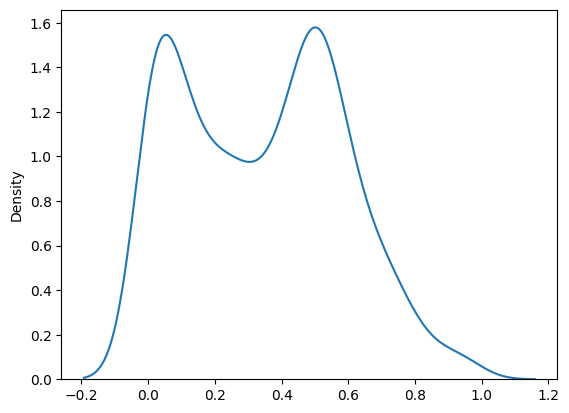

In [31]:
import seaborn as sns

sns.kdeplot(results3.cpu().numpy())

In [11]:
colors = ['blue','green','black', 'orange', 'yellow']

In [12]:
for predicted_frame_start, sps in zip(frames, starting_points):
    print("******** Frame start", predicted_frame_start)
    for sp in sps:
        print("Predicting from", sp)
        frame_pos=torch.tensor(sp)
        print("draw color magenta")
        print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")
        start=predicted_frame_start+1
        step=1
        bias_r=1
        lower=2.
        outer_have_pos = True
        got_below_15_ever = False
        got_below_18_ever = False

        for start in range(start+0,start+end-1):
            if step/end >= 0.75:
                bias_r=2.
            if step >= 10 and not got_below_18_ever:
                print("Breaking for distance:", predicted_frame_start, sp)
                outer_have_pos = False
                break
            if step >= 15 and not got_below_15_ever:
                print("Breaking for distance:", predicted_frame_start, sp)
                outer_have_pos = False
                break
            distance=torch.norm(frame_pos)
            print("Distance",distance)
            torch.cuda.empty_cache()
            color=colors[start % 5]
            print("START:", start)
            u.trajectory[start]
            coords = torch.tensor(u.atoms.positions.copy())

            protein_coords_traj_use = coords[nogas] # without gas
            translated = protein_coords_traj_use - protein_coords_traj_use.cpu()[cat].numpy()
            
            protein_coords_traj = coords[protein_cofactors] # with gas
            new_traj = md.Trajectory(xyz=((coords-protein_coords_traj.cpu()[cat].numpy())/10).numpy(), topology=traj.topology)
            new_traj.save('translated_frame%d_Sim%d.pdb'%(start,Sim))

            protein_coords_traj2 = coords[protein_cofactors]
            translated2 = protein_coords_traj2 - protein_coords_traj2.cpu()[cat].numpy()

            if distance > 17:
                radius=8
                space=0.75
                xyz2=get_points(start, translated, frame_pos, space=space, bottom_threshold=lower, top_threshold=3.5, max_radius=7.)
            elif distance > 15:
                radius=8
                space=0.75
                xyz2=get_points(start, translated, frame_pos, space=space, bottom_threshold=lower, top_threshold=3.5, max_radius=6.)
            else:
                if distance < 7.5:
                    space=0.4
                    radius=4.
                    threshold=lower
                elif distance < 9:
                    space=0.45
                    radius=4.
                    threshold=lower
                else:
                    space=0.50
                    radius=4.
                    threshold=lower
                print("SPACE:",space)
                xyz2=get_points(start, translated, frame_pos, space=space, bottom_threshold=threshold, top_threshold=3.5, max_radius=radius, distance_to=distance)
                
            print(xyz2.shape)
            if xyz2.shape[0] < 10: # even a large space might make this bigger depending on the grid boundaries cross the location
                # use default radius
                xyz2=get_points(start, translated, frame_pos, space=0.4, bottom_threshold=1.9)
                print(xyz2.shape)

            if distance >= 2:
                xyz2, pos_embedding = embed(xyz2, step=step, protein_coords_list=translated,protein_cofactors=protein_cofactors,global_to_local=global_to_local, radius=6, frame_emb=frame_emb)

            
            if distance >= 2:
                print('#################################')
                torch.cuda.empty_cache()
                index, frame_pos__, results = predict(pos_embedding, model='/data/pompei/bw973/Oxygenases/PHD2/PHD2_O2QD/Bundle/Sim5/model9_FE2dis_inrWater5.pt', bs=3,frame_emb_bool=True, node_input_bool=False, atom_as_node_attr=False) # 
                torch.cuda.empty_cache()
            if distance > 8:
                bias=get_fe_bias(xyz2, frame_pos, alpha=5000.0, beta=0.001, denom=8, range_=bias_r, point=[0,0,0])
            else:
                bias=get_fe_bias(xyz2, frame_pos, alpha=5000.0, beta=0.001, denom=8, range_=bias_r)
            results_biased = results * (1+bias.to('cuda'))
            print("results_biased:", results_biased.mean())
            total_positives = (results_biased>0.5).sum()
            if len(pos_embedding) < 500:
                if (distance < 10 and total_positives < 5) or len(pos_embedding)==1:
                    print("k=1")
                    scores, points, have_positives = topk_with_radius(results_biased, pos_embedding, k=1, radius=1, threshold=0.5)
                elif distance < 12 and total_positives < 20:
                    print("k=2")
                    scores, points, have_positives = topk_with_radius(results_biased, pos_embedding, k=2, radius=1, threshold=0.5)
                else:
                    print("k=3")
                    scores, points, have_positives = topk_with_radius(results_biased, pos_embedding, k=3, radius=2, threshold=0.5)
            else:
                print("k=3, len(pos_embedding)", len(pos_embedding))
                scores, points, have_positives = topk_with_radius(results_biased, pos_embedding, k=3, radius=3, threshold=0.5)
            
            if not have_positives:
                print("Breaking for  low results:", predicted_frame_start, sp)
                outer_have_pos = False
                break

            top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]
            for key, vals in top10:
                frame_pos=points[vals['nn_idx']].mean(axis=0)
                print("draw color %s" % color)
                # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
                print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 0.5")

            
            
            iron_dis=torch.norm(frame_pos)
            if iron_dis < 15:
                got_below_15_ever = True
            if iron_dis < 18:
                got_below_18_ever = True
            write_pdb2(torch.arange(0,len(pos_embedding)),results,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '.pdb')
            write_pdb2(torch.arange(0,len(pos_embedding)),results_biased,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '_biased.pdb')
            write_pdb2(torch.arange(0,len(pos_embedding)),bias,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '_bias.pdb')
            print('mol addfile translated_frame%d_Sim%d.pdb'%(start,Sim))
            step+=1

            print("\tDistance to iron:", iron_dis)
            
            d2=torch.norm(translated2-frame_pos, dim=1)
            distance_to_sp = torch.norm(frame_pos-sp)
            print("\tDistance from sp:", distance_to_sp)
            # d3=torch.norm(translated2-frame_pos, dim=1)
            try:
                print("\tClosest atom this frame %s, %s: %f" % (rnames2[d2.argmin()], anames2[d2.argmin()], d2.min()))
                # print("\tClosest atom next frame %s, %s: %f" % (rnames2[d3.argmin()], anames2[d3.argmin()], d3.min()))
            except:
                print("Closest or another oxygen")
            if iron_dis > 31:
                break
            if iron_dis < 6:
                break 
            if distance_to_sp < 3 and step > 10:
                break

        if not outer_have_pos:
            print("Breaking for:", predicted_frame_start, sp)
            continue

        print("")
        print("")


******** Frame start 0
Predicting from [-18.7  -0.1   2. ]
draw color magenta
draw sphere { -18.7 -0.1 2.0 } radius 1
Distance tensor(18.8069)
START: 1
tensor(18.8069) 20.0 3.5
torch.Size([114, 3])
STEP: 1
#################################
results_biased: tensor(0.1839, device='cuda:0')
k=3
Keeping: torch.Size([14]) , at score >= 0.5
draw color green
draw sphere { -18.75 0.25 2.0 } radius 0.5
1_Sim2_frame1_of_150.pdb
1_Sim2_frame1_of_150_biased.pdb
1_Sim2_frame1_of_150_bias.pdb
mol addfile translated_frame1_Sim2.pdb
	Distance to iron: tensor(18.8580)
	Distance from sp: tensor(0.3536)
	Closest atom this frame TYR384, HD2: 2.431464
Distance tensor(18.8580)
START: 2
tensor(18.8580) 20.0 3.5
torch.Size([96, 3])
STEP: 2
#################################
results_biased: tensor(0.2881, device='cuda:0')
k=3
Keeping: torch.Size([24]) , at score >= 0.5
draw color black
draw sphere { -19.0 0.75 2.25 } radius 0.5
2_Sim2_frame2_of_150.pdb
2_Sim2_frame2_of_150_biased.pdb
2_Sim2_frame2_of_150_bias.pd

KeyboardInterrupt: 

In [12]:
colors = ['blue','green','black', 'orange', 'yellow']

frame_pos_bests = []
frame_pos_bests_dist = []

# frame_pos=torch.tensor([-1.75, -1.00, -21.25]) # 0 equil pmain
# frame_pos=torch.tensor([-1.15, -1.9, -20.5]) # 0 equil pmain -1.15 -1.9 -20.5
frame_pos=torch.tensor([-7., -0.25, -17.5]) # pm
# frame_pos=torch.tensor([-7.75, -4., -11.5]) # pm
# frame_pos=torch.tensor([2.75, -21.1, 0.65]) # p4 2.75 -21.1 0.65
# frame_pos=torch.tensor([-3.25, -11.65, -3.5]) # p4 -3.25 -11.65 -3.5
# frame_pos=torch.tensor([4.25, -12.25, -2.5]) # p4
# frame_pos=torch.tensor([9.35, 10.85, 11.0]) # pr 9.35 10.85 11.0
print("draw color magenta")
print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")

bias_r=2.5
lower=2.
space=0.75
distance=torch.norm(frame_pos)
predicted_frame_start = 0
start=predicted_frame_start+1
start=102
step=2
# frame_pos=torch.tensor([4.75, 12.5, 2.0])
frame_pos=torch.tensor([ 6.5, 7.75, -12.75])
for start in range(start+0,start+end-1):
# for start in range(start+0,start+1):
    if step/end >= 0.75:
        bias_r=5.
    distance=torch.norm(frame_pos)
    print("Distance",distance)
    torch.cuda.empty_cache()
    color=colors[start % 5]
    print("START:", start)
    u.trajectory[start]
    coords = torch.tensor(u.atoms.positions.copy())

    protein_coords_traj_use = coords[nogas] # without gas
    translated = protein_coords_traj_use - protein_coords_traj_use.cpu()[cat].numpy()
    
    protein_coords_traj = coords[protein_cofactors] # with gas
    new_traj = md.Trajectory(xyz=((coords-protein_coords_traj.cpu()[cat].numpy())/10).numpy(), topology=traj.topology)
    new_traj.save('translated_frame%d_Sim%d.pdb'%(start,Sim))

    protein_coords_traj2 = coords[protein_cofactors]
    translated2 = protein_coords_traj2 - protein_coords_traj2.cpu()[cat].numpy()

    if distance > 17:
        radius=8
        space=0.75
        xyz2=get_points(start, translated, frame_pos, space=space, bottom_threshold=lower, top_threshold=3.5, max_radius=7.)
    elif distance > 15:
        radius=8
        space=0.75
        xyz2=get_points(start, translated, frame_pos, space=space, bottom_threshold=lower, top_threshold=3.5, max_radius=6.)
    else:
        if distance < 7.5:
            space=0.4
            radius=4.
            threshold=lower
        elif distance < 9:
            space=0.45
            radius=4.
            threshold=lower
        else:
            space=0.50
            radius=4.
            threshold=lower
        print("SPACE:",space)
        xyz2=get_points(start, translated, frame_pos, space=space, bottom_threshold=threshold, top_threshold=3.5, max_radius=radius, distance_to=distance)
        
    print(xyz2.shape)
    if xyz2.shape[0] < 10: # even a large space might make this bigger depending on the grid boundaries cross the location
        # use default radius
        xyz2=get_points(start, translated, frame_pos, space=0.4, bottom_threshold=1.9)
        print(xyz2.shape)

    if distance >= 2:
        xyz2, pos_embedding = embed(xyz2, step=step, protein_coords_list=translated,protein_cofactors=protein_cofactors,global_to_local=global_to_local, radius=6, frame_emb=frame_emb)

    
    if distance >= 2:
        print('#################################')
        torch.cuda.empty_cache()
        index, frame_pos__, results = predict(pos_embedding, model='/data/pompei/bw973/Oxygenases/PHD2/PHD2_O2QD/Bundle/Sim5/model9_FE2dis_inrWater6.pt', bs=10,frame_emb_bool=True, node_input_bool=False, atom_as_node_attr=False) # 

    if distance > 8:

        bias=get_fe_bias(xyz2, frame_pos, alpha=5000.0, beta=0.001, denom=8, range_=bias_r, point=[0,0,0])
    else:
        bias=get_fe_bias(xyz2, frame_pos, alpha=5000.0, beta=0.001, denom=8, range_=bias_r)
    results_biased = results * (1+bias.to('cuda'))
    print("results_biased:", results_biased.mean())
    total_positives = (results_biased>0.5).sum()
    if len(pos_embedding) < 500:
        if (distance < 10 and total_positives < 5) or len(pos_embedding)==1:
            print("k=1")
            scores, points, hp = topk_with_radius(results_biased, pos_embedding, k=1, radius=1, threshold=0.5)
        elif distance < 12 and total_positives < 20:
            print("k=2")
            scores, points, hp = topk_with_radius(results_biased, pos_embedding, k=2, radius=1, threshold=0.5)
        else:
            print("k=3")
            scores, points, hp = topk_with_radius(results_biased, pos_embedding, k=3, radius=2, threshold=0.5)
    else:
        print("k=3, len(pos_embedding)", len(pos_embedding))
        scores, points, hp = topk_with_radius(results_biased, pos_embedding, k=3, radius=3, threshold=0.5)

    top10 = sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True)[:1]
    for key, vals in top10:
        frame_pos=points[vals['nn_idx']].mean(axis=0)
        print("draw color %s" % color)
        # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
        print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 0.5")

    
    frame_pos_bests.append(frame_pos)
    frame_pos_bests_dist.append(torch.norm(frame_pos))
    write_pdb2(torch.arange(0,len(pos_embedding)),results,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '.pdb')
    write_pdb2(torch.arange(0,len(pos_embedding)),results_biased,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '_biased.pdb')
    write_pdb2(torch.arange(0,len(pos_embedding)),bias,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_Sim%d_frame'%Sim + str(step) + '_of_' + str((end)) + '_bias.pdb')
    print('mol addfile translated_frame%d_Sim%d.pdb'%(start,Sim))
    step+=1

    print("\tDistance to iron:", frame_pos_bests_dist[-1])
    
    d2=torch.norm(translated2-frame_pos, dim=1)
    # d3=torch.norm(translated2-frame_pos, dim=1)
    try:
        print("\tClosest atom this frame %s, %s: %f" % (rnames2[d2.argmin()], anames2[d2.argmin()], d2.min()))
        # print("\tClosest atom next frame %s, %s: %f" % (rnames2[d3.argmin()], anames2[d3.argmin()], d3.min()))
    except:
        print("Closest or another oxygen")
    if frame_pos_bests_dist[-1] > 31:
        break
    if frame_pos_bests_dist[-1] < 6:
        break

draw color magenta
draw sphere { -7.0 -0.25 -17.5 } radius 1
Distance tensor(16.2750)
START: 102
tensor(16.2750) 20.0 3.5
torch.Size([46, 3])
STEP: 2
#################################
results_biased: tensor(0.0016, device='cuda:0')
k=3
0 0.5
0 0.25
0 0.25
0 0.125
0 0.125
0 0.5
0 0.5
0 0.25
0 0.25
0 0.125
0 0.125
Keeping: torch.Size([0]) , at score >= 0.0625
102_Sim2_frame2_of_150.pdb
102_Sim2_frame2_of_150_biased.pdb
102_Sim2_frame2_of_150_bias.pdb
mol addfile translated_frame102_Sim2.pdb
	Distance to iron: tensor(16.2750)
	Closest atom this frame ALA399, HB1: 1.961614
Distance tensor(16.2750)
START: 103
tensor(16.2750) 20.0 3.5


KeyboardInterrupt: 

In [14]:
results_biased.max()

tensor(0.0197, device='cuda:0')

In [ ]:
scores, points, hp = topk_with_radius(results_biased, pos_embedding, k=3, radius=3, threshold=0.5)